In [44]:
import pandas as pd
import numpy as np 
import keras


TrainData = pd.read_csv("./Dados/DataSpline.csv")
TrainData.index = (np.arange(0, len(TrainData), 1).astype(float) * 0.07).round(5)
TrainData = TrainData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [4]:
import pandas as pd
import numpy as np 
import keras

TrainData = pd.read_csv("./Dados/Data.csv")
TrainData.index = (np.arange(0, len(TrainData), 1).astype(float) * 0.07).round(5)
TrainData = TrainData.drop(columns=["X", "Y", "tempo"])
TrainData = TrainData.rename(columns={
    "VD": "Wd",
    "VE": "We",
    "Theta": "theta(Wd,We)",
    "Setpoint VD": "Wd_true",
    "Setpoint VE": "We_true",
})
print(TrainData.head())

RESTRICTIONS = ["Wd_true", "We_true"]

Restrictions_data = TrainData[RESTRICTIONS].to_numpy()
print(Restrictions_data.shape)

      theta(Wd,We)  Wd_true  We_true    Wd    We
0.00           0.0      0.0      0.0  0.00  0.00
0.07           0.0      0.0      0.0  2.33  2.33
0.14           0.0      0.0      0.0  2.33  2.33
0.21           0.0      0.0      0.0  2.33  2.33
0.28           0.0      0.0      0.0  2.33  2.33
(2146, 2)


In [5]:
TestData = pd.read_csv("./Dados/DataSpline2.csv")
TestData.index = (np.arange(0, len(TestData), 1).astype(float) * 0.07).round(5)
TestData = TestData.drop(columns=["x(Wd,We)", "y(Wd,We)"])
print(TestData.columns)


Index(['Unnamed: 0', 'Wd', 'We', 'theta(Wd,We)'], dtype='object')


Dados 'ValData' carregados com sucesso.

Gráfico salvo como 'heatmap_correlacao.png'

Matriz de Correlação calculada:
                    theta(Wd,We)  Wd_lag_1  Wd_lag_2  Wd_lag_3  We_lag_1  \
theta(Wd,We)            1.000000 -0.026968 -0.027176 -0.027366  0.001896   
Wd_lag_1               -0.026968  1.000000  0.999893  0.999577  0.955759   
Wd_lag_2               -0.027176  0.999893  1.000000  0.999893  0.955211   
Wd_lag_3               -0.027366  0.999577  0.999893  1.000000  0.954540   
We_lag_1                0.001896  0.955759  0.955211  0.954540  1.000000   
We_lag_2                0.001041  0.956180  0.955757  0.955209  0.999869   
We_lag_3                0.000174  0.956477  0.956177  0.955754  0.999482   
theta(Wd,We)_lag_1      0.999973 -0.028637 -0.028864 -0.029072  0.000880   
theta(Wd,We)_lag_2      0.999891 -0.030296 -0.030541 -0.030768 -0.000156   
theta(Wd,We)_lag_3      0.999754 -0.031946 -0.032209 -0.032454 -0.001210   

                    We_lag_2  We_lag_3  theta

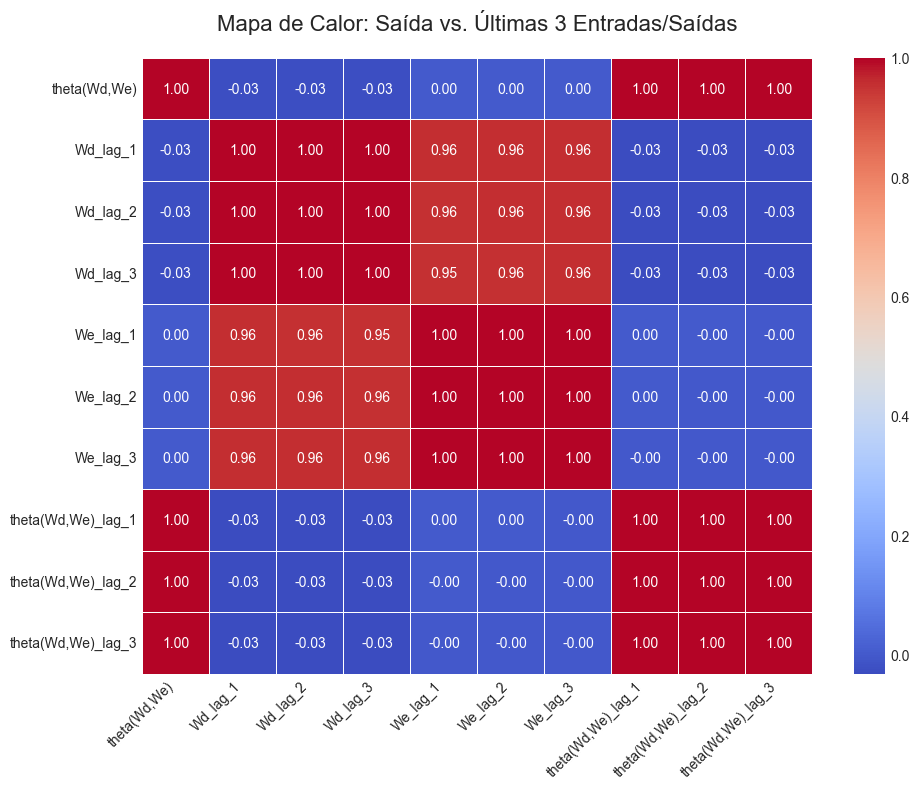

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carregamento e Preparação dos Dados ---
# OBSERVAÇÃO: SUBSTITUA ESTA SEÇÃO DE CÓDIGO PELA SUA.
# O código abaixo é apenas para simular seus dados e tornar o script executável.
try:
    # Cole o seu código de carregamento de dados aqui
    ValData = pd.read_csv("./Dados/DataSpline3.csv")
    ValData.index = (np.arange(0, len(ValData), 1).astype(float) * 0.07).round(5)
    ValData = ValData.drop(columns=["x(Wd,We)", "y(Wd,We)"])
    print("Dados 'ValData' carregados com sucesso.")
except FileNotFoundError:
    print("Arquivo './Dados/DataSpline3.csv' não encontrado.")
    print("Gerando dados de amostra para demonstração...")
    # Geração de dados de amostra se o arquivo real não for encontrado
    np.random.seed(42) # Garante que os dados aleatórios sejam sempre os mesmos
    data_size = 500
    ValData = pd.DataFrame({
        'Wd': np.random.uniform(1, 15, data_size),
        'We': np.random.uniform(-10, 10, data_size),
        'theta(Wd,We)': np.sin(np.linspace(0, 15 * np.pi, data_size)) + np.random.randn(data_size) * 0.2
    })
# --- FIM DA SEÇÃO DE SUBSTITUIÇÃO ---


# --- 2. Definição de Preditores, Alvo e Número de Lags ---
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"
N_LAGS = 3 # Número de defasagens (passos anteriores) a analisar


# --- 3. Função para Criar Features Defasadas (Lags) ---
def create_lagged_features(df, variable_names, n_lags):
    """
    Cria e retorna um DataFrame contendo as features defasadas para as 
    variáveis especificadas.
    """
    lagged_df = pd.DataFrame()
    for var_name in variable_names:
        for i in range(1, n_lags + 1):
            # Cria uma nova coluna com os dados da variável deslocados 'i' posições
            lagged_df[f'{var_name}_lag_{i}'] = df[var_name].shift(i)
    return lagged_df


# --- 4. Construção do DataFrame para Análise ---
# Cria as features defasadas para as entradas (PREDICTORS)
lagged_inputs = create_lagged_features(ValData, PREDICTORS, N_LAGS)

# Cria as features defasadas para a saída (TARGET)
lagged_output = create_lagged_features(ValData, [TARGET], N_LAGS)

# Combina a saída atual com todas as features defasadas em um único DataFrame
analysis_df = pd.concat([ValData[[TARGET]], lagged_inputs, lagged_output], axis=1)

# Remove as primeiras linhas que contêm valores NaN devido à operação de shift
analysis_df.dropna(inplace=True)


# --- 5. Cálculo da Correlação e Geração do Mapa de Calor ---
# Calcula a matriz de correlação entre todas as variáveis no DataFrame
correlation_matrix = analysis_df.corr()

# Configura o estilo do gráfico
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8)) # Define o tamanho da figura

# Cria o mapa de calor usando a biblioteca seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,          # Exibe os valores de correlação no mapa
    cmap='coolwarm',     # Define o esquema de cores (quente=positivo, frio=negativo)
    fmt=".2f",           # Formata os números para duas casas decimais
    linewidths=.5,       # Adiciona linhas entre as células
    ax=ax
)

# Ajusta as legendas e o título
ax.set_title(f'Mapa de Calor: Saída vs. Últimas {N_LAGS} Entradas/Saídas', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rotaciona os labels do eixo X para melhor leitura
plt.yticks(rotation=0)
plt.tight_layout() # Ajusta o layout para evitar sobreposição

# Salva a imagem do gráfico em um arquivo
output_filename = 'heatmap_correlacao.png'
plt.savefig(output_filename)

print(f"\nGráfico salvo como '{output_filename}'")
print("\nMatriz de Correlação calculada:")
print(correlation_matrix)


In [6]:
ValData = pd.read_csv("./Dados/DataSpline3.csv")
ValData.index = (np.arange(0, len(ValData), 1).astype(float) * 0.07).round(5)
ValData = ValData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [7]:
# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()

(2146, 2)


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

def compile_model(model, epochs=5000):
    # Compila e treina o modelo
    model.compile(loss="mse", optimizer="adam")
    history = model.fit(train_x, train_y, epochs=epochs, validation_data=(x_val, y_val), verbose=False)

    # Previsões
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # Cálculo das métricas
    metrics = {
        'Training': {
            'R2': r2_score(train_y, train_pred),
            'MSE': mean_squared_error(train_y, train_pred),
            'RMSE': root_mean_squared_error(train_y, train_pred),
            'MAPE': mean_absolute_percentage_error(train_y, train_pred)
        },
        'Validation': {
            'R2': r2_score(y_val, val_pred),
            'MSE': mean_squared_error(y_val, val_pred),
            'RMSE': root_mean_squared_error(y_val, val_pred),
            'MAPE': mean_absolute_percentage_error(y_val, val_pred)
        },
        'Test': {
            'R2': r2_score(y_test, test_pred),
            'MSE': mean_squared_error(y_test, test_pred),
            'RMSE': root_mean_squared_error(y_test, test_pred),
            'MAPE': mean_absolute_percentage_error(y_test, test_pred)
        }
    }

    # Imprime as métricas
    for name, m in metrics.items():
        print(f"\n{name} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")

    # Gráfico do histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráficos comparativos
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    datasets = [
        ('Treinamento', train_y, train_pred),
        ('Validação', y_val, val_pred),
        ('Teste', y_test, test_pred)
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)
        axs[i].plot(y_true, marker='o', label='Amostras Reais')
        axs[i].plot(y_pred, marker='x', label='Valores Preditos')
        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Índice')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return metrics


In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

# Certifique-se de que as variáveis train_x, train_y, x_val, y_val, x_test, y_test e
# a função root_mean_squared_error estejam definidas no seu ambiente.
# Exemplo de como você poderia defini-las para testar:
# from sklearn.model_selection import train_test_split
# X = np.random.rand(100, 10).astype(np.float32)
# Y = np.random.rand(100, 1).astype(np.float32)
# train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=0.2, random_state=42)
# x_val, x_test, y_val, y_test = train_test_split(test_x, test_y, test_size=0.5, random_state=42)

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def custom_train_model(model, epochs=5000):
    # Definindo o otimizador e a função de perda
    optimizer = Adam()
    loss_fn = MeanSquaredError()

    train_loss_history = []
    val_loss_history = []

    # Loop de treinamento manual
    print("Iniciando o treinamento manual com derivada automática...")
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            # Previsões no conjunto de treinamento
            train_predictions = model(train_x, training=True)
            # Cálculo da perda de treinamento
            loss = loss_fn(train_y, train_predictions)

        # Cálculo dos gradientes
        gradients = tape.gradient(loss, model.trainable_variables)
        # Aplicação dos gradientes para atualizar os pesos do modelo
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # Avaliação no conjunto de validação (sem cálculo de gradientes)
        val_predictions = model(x_val, training=False)
        val_loss = loss_fn(y_val, val_predictions)

        train_loss_history.append(loss.numpy())
        val_loss_history.append(val_loss.numpy())

        if (epoch + 1) % 500 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.numpy():.4f}, Val Loss: {val_loss.numpy():.4f}")

    # Criando um objeto history para compatibilidade com a função original
    # (apenas para o plot, model.fit retorna um History object completo)
    class CustomHistory:
        def __init__(self, train_losses, val_losses):
            self.history = {'loss': train_losses, 'val_loss': val_losses}

    history = CustomHistory(train_loss_history, val_loss_history)

    # Previsões após o treinamento
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # Cálculo das métricas
    metrics = {
        'Training': {
            'R2': r2_score(train_y, train_pred),
            'MSE': mean_squared_error(train_y, train_pred),
            'RMSE': root_mean_squared_error(train_y, train_pred),
            'MAPE': mean_absolute_percentage_error(train_y, train_pred)
        },
        'Validation': {
            'R2': r2_score(y_val, val_pred),
            'MSE': mean_squared_error(y_val, val_pred),
            'RMSE': root_mean_squared_error(y_val, val_pred),
            'MAPE': mean_absolute_percentage_error(y_val, val_pred)
        },
        'Test': {
            'R2': r2_score(y_test, test_pred),
            'MSE': mean_squared_error(y_test, test_pred),
            'RMSE': root_mean_squared_error(y_test, test_pred),
            'MAPE': mean_absolute_percentage_error(y_test, test_pred)
        }
    }

    # Imprime as métricas
    for name, m in metrics.items():
        print(f"\n{name} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")

    # Gráfico do histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráficos comparativos
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    datasets = [
        ('Treinamento', train_y, train_pred),
        ('Validação', y_val, val_pred),
        ('Teste', y_test, test_pred)
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)
        axs[i].plot(y_true, marker='o', label='Amostras Reais')
        axs[i].plot(y_pred, marker='x', label='Valores Preditos')
        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Índice')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return metrics

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

# Função auxiliar para RMSE (garante compatibilidade com numpy e tensores)
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))


def custom_train_model_with_es(model, 
                               train_x, train_y, 
                               x_val, y_val, 
                               x_test, y_test, 
                               epochs=5000, patience=50, min_delta=0, plot=True, learning_rate=0.001):
    """
    Treina um modelo Keras usando derivada automática com tf.GradientTape e Early Stopping.

    Args:
        model: O modelo Keras a ser treinado.
        train_x, train_y: Conjunto de dados de treinamento (entradas e saídas).
        x_val, y_val: Conjunto de dados de validação.
        x_test, y_test: Conjunto de dados de teste.
        epochs: Número máximo de épocas para o treinamento.
        patience: Número de épocas sem melhora na val_loss antes de parar o treinamento.
        min_delta: Mudança mínima na val_loss para ser considerada uma melhora.
        plot: Booleano para indicar se os gráficos devem ser exibidos.
        learning_rate: A taxa de aprendizado para o otimizador Adam.
    """
    
    # GARANTIA DE TIPAGEM: Converte todos os dados para tensores TensorFlow (tf.float32) 
    # se ainda não forem, o que é necessário para o GradientTape.
    train_x = tf.constant(train_x, dtype=tf.float32) if not tf.is_tensor(train_x) else tf.cast(train_x, dtype=tf.float32)
    train_y = tf.constant(train_y, dtype=tf.float32) if not tf.is_tensor(train_y) else tf.cast(train_y, dtype=tf.float32)
    x_val = tf.constant(x_val, dtype=tf.float32) if not tf.is_tensor(x_val) else tf.cast(x_val, dtype=tf.float32)
    y_val = tf.constant(y_val, dtype=tf.float32) if not tf.is_tensor(y_val) else tf.cast(y_val, dtype=tf.float32)
    x_test = tf.constant(x_test, dtype=tf.float32) if not tf.is_tensor(x_test) else tf.cast(x_test, dtype=tf.float32)
    y_test = tf.constant(y_test, dtype=tf.float32) if not tf.is_tensor(y_test) else tf.cast(y_test, dtype=tf.float32)

    # Definindo o otimizador e a função de perda
    optimizer = Adam(learning_rate=learning_rate)
    loss_fn = MeanSquaredError()

    train_loss_history = []
    val_loss_history = []

    # Variáveis para Early Stopping
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_weights = None 

    # Loop de treinamento manual
    print(f"Iniciando o treinamento manual (LR={learning_rate}, Paciência={patience})...")
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            # Previsões no conjunto de treinamento
            train_predictions = model(train_x, training=True)
            # Cálculo da perda de treinamento
            loss = loss_fn(train_y, train_predictions)

        # Cálculo dos gradientes
        gradients = tape.gradient(loss, model.trainable_variables)
        # Aplicação dos gradientes para atualizar os pesos do modelo
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # Avaliação no conjunto de validação (sem cálculo de gradientes)
        val_predictions = model(x_val, training=False)
        val_loss = loss_fn(y_val, val_predictions)

        train_loss_history.append(loss.numpy())
        val_loss_history.append(val_loss.numpy())

        # Lógica de Early Stopping
        if val_loss.numpy() < best_val_loss - min_delta:
            best_val_loss = val_loss.numpy()
            epochs_no_improve = 0
            best_weights = model.get_weights() 
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 500 == 0 or epoch == 0 or epochs_no_improve >= patience:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.numpy():.4f}, Val Loss: {val_loss.numpy():.4f} (Melhora há {epochs_no_improve} épocas)")

        if epochs_no_improve >= patience:
            print(f"Early stopping! Validação não melhorou por {patience} épocas.")
            print(f"Melhor Val Loss: {best_val_loss:.4f} na época {epoch + 1 - epochs_no_improve}")
            if best_weights:
                model.set_weights(best_weights) 
                print("Pesos do modelo restaurados para a melhor época.")
            break 

    # Criando um objeto history para compatibilidade com a função original
    class CustomHistory:
        def __init__(self, train_losses, val_losses):
            self.history = {'loss': train_losses, 'val_loss': val_losses}

    history = CustomHistory(train_loss_history, val_loss_history)

    # Previsões após o treinamento
    # model.predict() geralmente retorna NumPy arrays
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred

    # Cálculo das métricas
    metrics = {
        'Training': {
            'R2': r2_score(train_y_np, train_pred_np),
            'MSE': mean_squared_error(train_y_np, train_pred_np),
            'RMSE': root_mean_squared_error(train_y_np, train_pred_np),
            'MAPE': mean_absolute_percentage_error(train_y_np, train_pred_np)
        },
        'Validation': {
            'R2': r2_score(y_val_np, val_pred_np),
            'MSE': mean_squared_error(y_val_np, val_pred_np),
            'RMSE': root_mean_squared_error(y_val_np, val_pred_np),
            'MAPE': mean_absolute_percentage_error(y_val_np, val_pred_np)
        },
        'Test': {
            'R2': r2_score(y_test_np, test_pred_np),
            'MSE': mean_squared_error(y_test_np, test_pred_np),
            'RMSE': root_mean_squared_error(y_test_np, test_pred_np),
            'MAPE': mean_absolute_percentage_error(y_test_np, test_pred_np)
        }
    }

    # Imprime as métricas
    for name, m in metrics.items():
        print(f"\n{name} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")

    if plot:
        # Gráfico do histórico de treinamento
        plt.figure(figsize=(8, 5))
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('MSE Loss')
        plt.title('Training History')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    return metrics

In [50]:
import keras

complex_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
compile_model(complex_dense_RNN)

KeyboardInterrupt: 

Iniciando o treinamento manual com derivada automática...
Epoch 1/5000, Train Loss: 0.5534, Val Loss: 0.3855
Epoch 500/5000, Train Loss: 0.1922, Val Loss: 0.2974
Epoch 1000/5000, Train Loss: 0.1885, Val Loss: 0.2938
Epoch 1500/5000, Train Loss: 0.1796, Val Loss: 0.3028
Epoch 2000/5000, Train Loss: 0.1123, Val Loss: 0.3578
Epoch 2500/5000, Train Loss: 0.0789, Val Loss: 0.3957
Epoch 3000/5000, Train Loss: 0.0681, Val Loss: 0.4108
Epoch 3500/5000, Train Loss: 0.0658, Val Loss: 0.4164
Epoch 4000/5000, Train Loss: 0.0638, Val Loss: 0.4127
Epoch 4500/5000, Train Loss: 0.0617, Val Loss: 0.4073
Epoch 5000/5000, Train Loss: 0.0557, Val Loss: 0.4278
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Training Metrics:
  R2: 0.7689
  MSE: 0.0557
  RMSE: 0.2361
  MAPE: 1.6158

Validation Metrics:
  R2: -0.8565
  MSE: 0.4278
  RMSE: 0.6540
  MAPE: 4.0092

Test Metrics:
  R2: -0.9347
  MSE: 0.3190
  RMSE: 0.5648
  MAPE: 1.6649


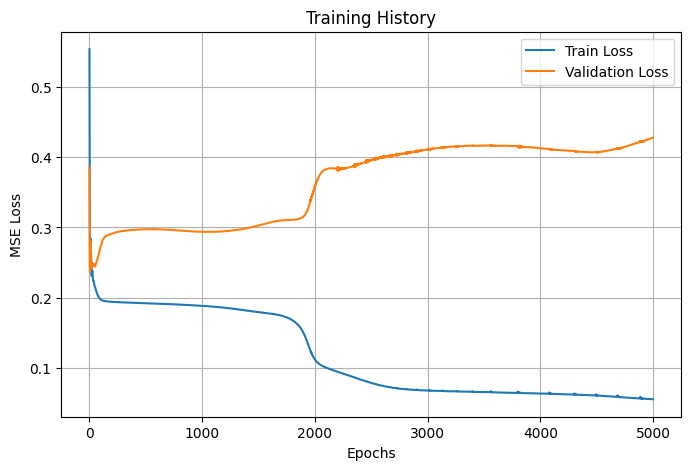

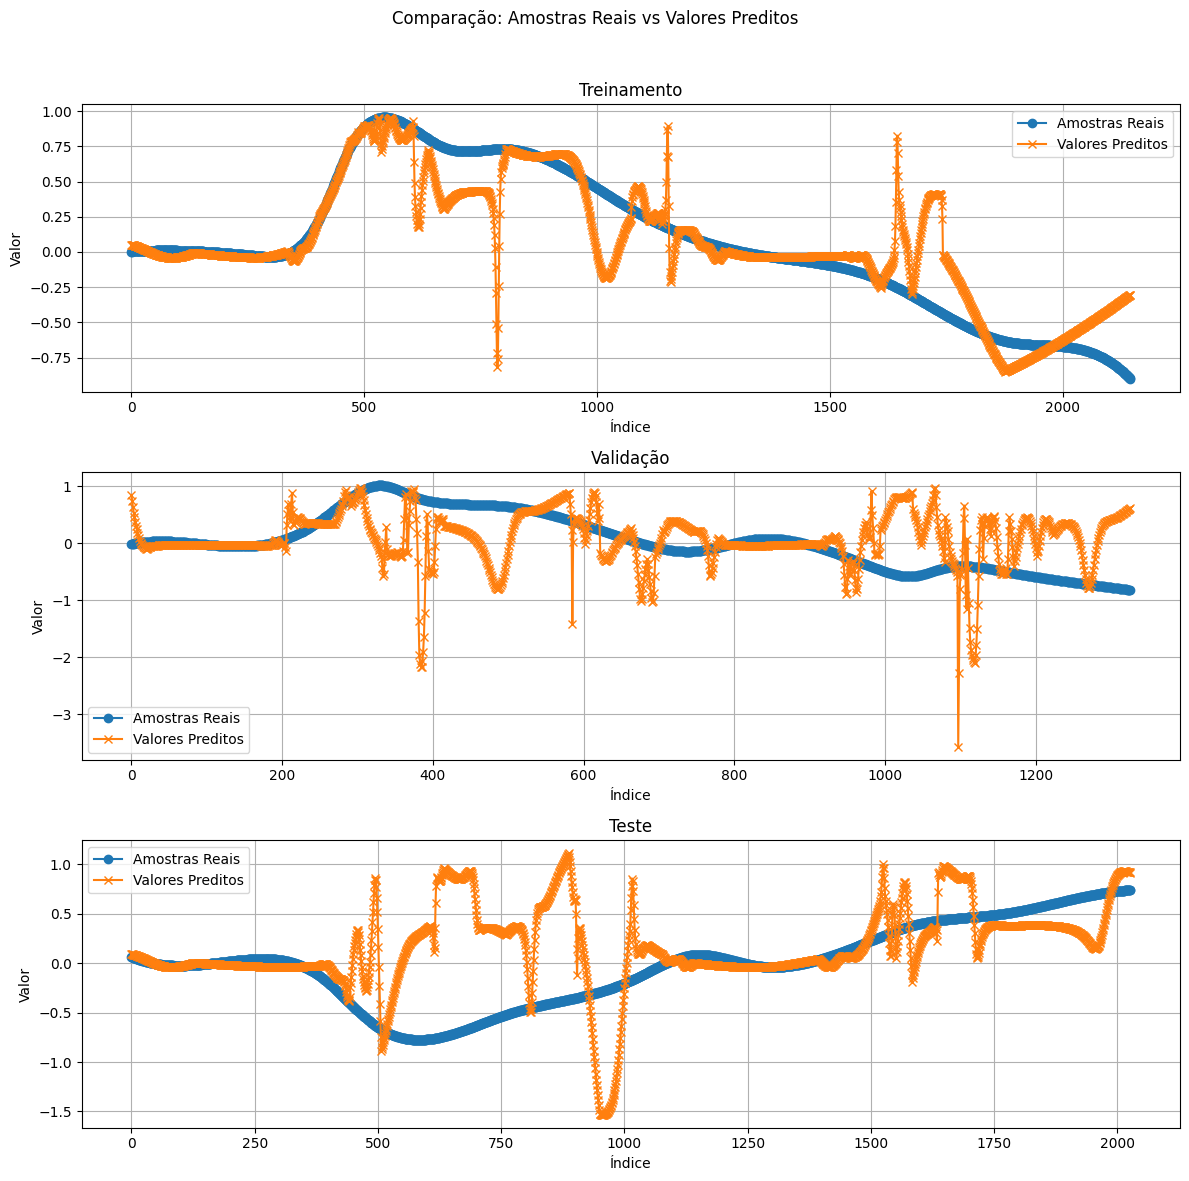

{'Training': {'R2': 0.7688700087291529,
  'MSE': 0.055732354301950955,
  'RMSE': 0.23607700926170458,
  'MAPE': 1.6158399825318086},
 'Validation': {'R2': -0.8565109787432097,
  'MSE': 0.42776133690534657,
  'RMSE': 0.6540346603241655,
  'MAPE': 4.009188757784309},
 'Test': {'R2': -0.9347266395206937,
  'MSE': 0.3189584132924852,
  'RMSE': 0.564764033285128,
  'MAPE': 1.6649323097056035}}

In [11]:
import keras

complex_dense_RNN_grad  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])

custom_train_model(complex_dense_RNN_grad)

In [ ]:

tf.random.set_seed(42)


complex_dense_RNN_ES  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])
custom_train_model_with_es(complex_dense_RNN_ES, learning_rate= 0.01)

NameError: name 'os' is not defined

In [12]:

def plot_model_metrics_by_neurons(all_models_metrics):
    """
    Plota graficamente as métricas de desempenho de diferentes modelos
    em função da quantidade de neurônios RNN, em uma única figura com 4 subplots.

    Args:
        all_models_metrics (list): Uma lista de dicionários, onde cada dicionário
                                   contém as métricas de um modelo (Training, Validation, Test)
                                   e o número de neurônios ('RNN_Units').
    """

    if not all_models_metrics:
        print("A lista all_models_metrics está vazia. Não há dados para plotar.")
        return

    # Extrair os números de neurônios e inicializar dicionários para armazenar os dados das métricas
    # Garantimos que os neurônios estejam ordenados para o eixo X
    rnn_units = sorted([m['RNN_Neurons'] for m in all_models_metrics])

    # Dicionário para armazenar os valores das métricas por tipo de métrica e conjunto de dados
    metrics_data = {
        'R2': {'Training': [], 'Validation': [], 'Test': []},
        'MSE': {'Training': [], 'Validation': [], 'Test': []},
        'RMSE': {'Training': [], 'Validation': [], 'Test': []},
        'MAPE': {'Training': [], 'Validation': [], 'Test': []},
    }

    # Preencher os dados das métricas
    # Iterar sobre os rnn_units para garantir que os dados estejam na ordem correta do eixo X
    for units in rnn_units:
        current_model_metrics = next(m for m in all_models_metrics if m['RNN_Neurons'] == units)

        for metric_name in metrics_data.keys():
            metrics_data[metric_name]['Training'].append(current_model_metrics['Training'][metric_name])
            metrics_data[metric_name]['Validation'].append(current_model_metrics['Validation'][metric_name])
            metrics_data[metric_name]['Test'].append(current_model_metrics['Test'][metric_name])

    # --- Início da parte modificada para 4 subplots ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # Cria uma figura com 2 linhas e 2 colunas de subplots
    axes = axes.flatten() # Achata o array de eixos para facilitar a iteração

    metric_names_order = ['R2', 'MSE', 'RMSE', 'MAPE'] # Define a ordem dos plots

    for i, metric_name in enumerate(metric_names_order):
        ax = axes[i] # Seleciona o subplot atual
        datasets = metrics_data[metric_name]

        ax.plot(rnn_units, datasets['Training'], marker='o', label='Training')
        ax.plot(rnn_units, datasets['Validation'], marker='x', label='Validation')
        ax.plot(rnn_units, datasets['Test'], marker='s', label='Test')

        ax.set_title(f'{metric_name} vs. Número de Neurônios')
        ax.set_xlabel('Número de Neurônios na Camada RNN')
        ax.set_ylabel(metric_name)
        ax.set_xticks(rnn_units) # Garante que apenas os valores de neurônios testados apareçam no eixo X
        ax.grid(True)
        ax.legend()

    plt.suptitle('Desempenho da Rede RNN por Número de Neurônios', fontsize=18, y=1.02) # Título geral da figura
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajusta o layout para evitar sobreposição, deixando espaço para o suptitle
    plt.show()

In [15]:
def create_sequences(input_data, target_data, timesteps):
    """
    Cria sequências de dados para treinamento de RNN.

    Args:
        input_data (np.array): Dados de entrada (X), formato (samples, features).
        target_data (np.array): Dados de saída (Y), formato (samples, target_features).
        timesteps (int): O número de passos de tempo passados a serem considerados.

    Returns:
        X_seq (np.array): Dados de entrada sequenciais, formato (N, timesteps, features).
        Y_seq (np.array): Dados de saída correspondentes, formato (N, target_features).
    """
    X_seq, Y_seq = [], []
    
    # Itera sobre os dados, começando após o número de timesteps
    for i in range(timesteps, len(input_data)):
        # A sequência de entrada (X_seq) é a janela de dados de i-timesteps até i
        X_seq.append(input_data[i-timesteps:i])
        
        # O alvo (Y_seq) é o valor de saída no passo de tempo atual 'i'
        Y_seq.append(target_data[i])
    
    return np.array(X_seq), np.array(Y_seq)

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            y_k   = y_pred[1:]
            y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:-1, 0]   # Wd
            x2_km1 = restrictions_data[:-1, 1]   # We

            # calcula derivada aproximada
            dy_dt = (y_k - y_km1) / Ts
            phys  = (R / L) * (x1_km1 - x2_km1)
            MSE_f = tf.reduce_mean(tf.square(dy_dt - phys))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % 50 == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4f}, MSE_d={MSE_d.numpy():.4f}, MSE_f={MSE_f.numpy():.4f}, Val MSE={val_d.numpy():.4f}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }

    for split, m in metrics.items():
        print(f"\n{split} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        print(model.trainable_variables)

    return metrics


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1, λ2=0
Epoch 1: Loss=0.5836, MSE_d=0.5836, MSE_f=0.3710, Val MSE=0.3916
Epoch 50: Loss=0.2369, MSE_d=0.2369, MSE_f=0.0967, Val MSE=0.2444
Epoch 100: Loss=0.2250, MSE_d=0.2250, MSE_f=0.1593, Val MSE=0.2386
Epoch 150: Loss=0.2218, MSE_d=0.2218, MSE_f=0.2337, Val MSE=0.2401
Epoch 200: Loss=0.2201, MSE_d=0.2201, MSE_f=0.2590, Val MSE=0.2386
Epoch 250: Loss=0.2189, MSE_d=0.2189, MSE_f=0.2679, Val MSE=0.2369
Epoch 300: Loss=0.2179, MSE_d=0.2179, MSE_f=0.2719, Val MSE=0.2360
Epoch 350: Loss=0.2170, MSE_d=0.2170, MSE_f=0.2729, Val MSE=0.2357
Epoch 400: Loss=0.2162, MSE_d=0.2162, MSE_f=0.2721, Val MSE=0.2355
Epoch 450: Loss=0.2154, MSE_d=0.2154, MSE_f=0.2719, Val MSE=0.2354
Epoch 500: Loss=0.2147, MSE_d=0.2147, MSE_f=0.2746, Val MSE=0.2353
Epoch 550: Loss=0.2139, MSE_d=0.2139, MSE_f=0.2811, Val MSE=0.2354
Epoch 600: Loss=0.2131, MSE_d=0.2131, MSE_f=0.2917, Val MSE=0.2356
Epoch 650: Loss=0.2122, MSE_d=0.2122, MSE_f=0.3069, Val MSE=0.2359
Epoch 700: Lo

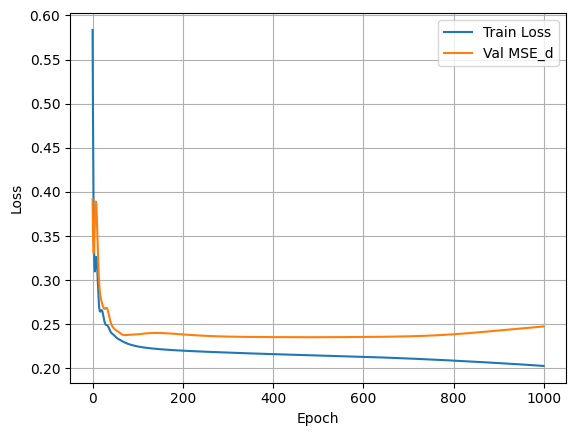

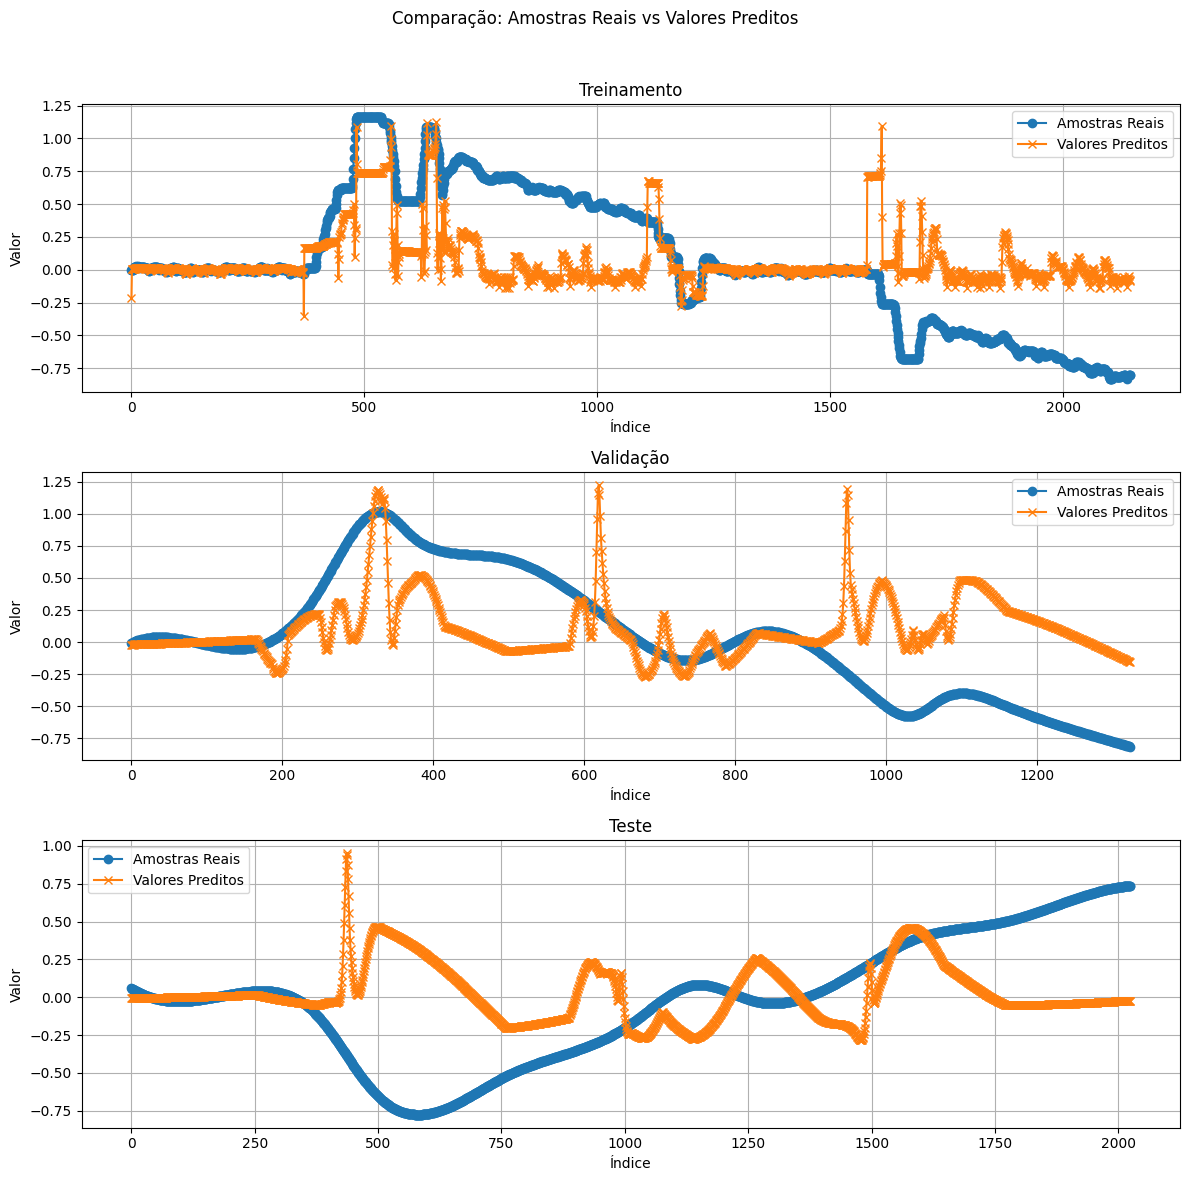

[<Variable path=sequential_1/simple_rnn_3/simple_rnn_cell/kernel, shape=(2, 20), dtype=float32, value=[[-0.50914055  0.3448686  -0.16456479 -0.17925298 -0.2994835  -0.00262415
   0.10940024  0.34205836 -0.05904483 -0.06909806 -0.28586853 -0.3931846
  -0.16320488  0.25963634  0.49327397 -0.45374542 -0.33812067 -0.43928707
  -0.44211102 -0.01336504]
 [-0.46926555 -0.4474921   0.03492572 -0.15774809 -0.3434613  -0.50848204
   0.2854361   0.4851072   0.2536746  -0.46925005 -0.15502617 -0.02184368
  -0.04224473 -0.46499273  0.5276904  -0.3866107   0.3241454   0.49204767
   0.16531444  0.29246768]]>, <Variable path=sequential_1/simple_rnn_3/simple_rnn_cell/recurrent_kernel, shape=(20, 20), dtype=float32, value=[[ 0.08199134  0.11026822 -0.09247421 -0.16622473  0.09296837  0.28651065
  -0.23845614  0.01780713 -0.15013386 -0.08810309  0.25237295 -0.38886675
  -0.1760287   0.0940365   0.08048611  0.43971533 -0.4550518  -0.37591764
  -0.21652499  0.22602159]
 [ 0.24322382 -0.16757907 -0.15053745

{'Training': {'R2': 0.21563172340393066,
  'MSE': 0.20276658236980438,
  'RMSE': 0.45029610521278596,
  'MAPE': 4023746297856.0},
 'Validation': {'R2': -0.07262551784515381,
  'MSE': 0.24751518666744232,
  'RMSE': 0.4975089814942463,
  'MAPE': 2.108196496963501},
 'Test': {'R2': -0.38281798362731934,
  'MSE': 0.2281871736049652,
  'RMSE': 0.47768941123387404,
  'MAPE': 2.6609818935394287}}

In [17]:
import os
import random

os.environ['PYTHONHASHSEED'] = '47'
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # força operações determinísticas no TF (em CPU/GPU)
random.seed(47)
np.random.seed(47)
tf.random.set_seed(47)


TIMESTEPS = 2
train_x_seq, train_y_seq = create_sequences(train_x, train_y, TIMESTEPS)
x_val_seq, y_val_seq = create_sequences(x_val, y_val, TIMESTEPS)
x_test_seq, y_test_seq = create_sequences(x_test, y_test, TIMESTEPS)

train_x_tensor = tf.constant(train_x_seq, dtype=tf.float32)
train_y_tensor = tf.constant(train_y_seq, dtype=tf.float32)
x_val_tensor = tf.constant(x_val_seq, dtype=tf.float32)
y_val_tensor = tf.constant(y_val_seq, dtype=tf.float32)
x_test_tensor = tf.constant(x_test_seq, dtype=tf.float32)
y_test_tensor = tf.constant(y_test_seq, dtype=tf.float32)

# O número de features é 2 ("Wd" e "We")
FEATURES = 2

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[TIMESTEPS, FEATURES]),
    keras.layers.SimpleRNN(15, return_sequences= True),
    keras.layers.SimpleRNN(10, return_sequences= False),
    keras.layers.Dense(1)
])

#custom_train_model_with_es(
#    model, 
#    train_x=train_x_tensor, train_y=train_y_tensor,
#    x_val=x_val_tensor, y_val=y_val_tensor,
#    x_test=x_test_tensor, y_test=y_test_tensor,
#    epochs=5000, 
#    learning_rate=0.001,
#    min_delta=0,
#    patience= 5)

custom_train_model_with_es_physics(
    model,
    train_x_seq, train_y_seq,
    x_val_seq,   y_val_seq,
    x_test_seq,  y_test_seq,
    restrictions_data= Restrictions_data,
    Ts=0.07,     # seu passo de amostragem
    L=0.123,       # valor de L
    R=0.034,       # valor de R
    lambda1= 1, # peso do MSE convencional
    lambda2=0, # peso do termo físico
    epochs=1000,
    patience = 6,
    min_delta=0,
    plot=True,
    learning_rate=0.001,
    use_early_stopping=False
)


In [101]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# Utilitários

def pack_weights(vars):
    return tf.concat([tf.reshape(v, [-1]) for v in vars], axis=0)

def unpack_weights(vars, flat):
    idx = 0
    for v in vars:
        shape = v.shape
        size = tf.reduce_prod(shape)
        new_val = flat[idx: idx + size]
        v.assign(tf.reshape(new_val, shape))
        idx += size

# Função de treinamento com Levenberg-Marquardt

def custom_train_model_with_lm(model,
                               train_x, train_y,
                               x_val, y_val,
                               Ts, L, R,
                               lambda1=1.0, lambda2=1.0,
                               max_iters=100,
                               initial_mu=1e-3,
                               nu=10,
                               plot=True):
    """
    Treina modelo usando passo de Levenberg-Marquardt em vez de SGD.
    """
    # conversão de dados
    train_x = tf.convert_to_tensor(train_x, dtype=tf.float32)
    train_y = tf.convert_to_tensor(train_y, dtype=tf.float32)
    x_val    = tf.convert_to_tensor(x_val,    dtype=tf.float32)
    y_val    = tf.convert_to_tensor(y_val,    dtype=tf.float32)

    vars = model.trainable_variables
    mse = tf.keras.losses.MeanSquaredError()

    # histórico
    history = []
    mu = initial_mu

    for it in range(max_iters):
        with tf.GradientTape(persistent=True) as tape:
            # predição e resíduos
            y_pred = model(train_x, training=True)                # [N,1]
            residuals = tf.reshape(y_pred - train_y, [-1, 1])     # [N,1]
            loss_data = mse(train_y, y_pred)
            # termo físico
            y_k   = y_pred[1:]
            y_km1 = y_pred[:-1]
            x1_km1 = train_x[:-1, 0]
            x2_km1 = train_x[:-1, 1]
            dy_dt = (y_k - y_km1) / Ts
            phys  = (R/L) * (x1_km1 - x2_km1)
            loss_phys = tf.reduce_mean(tf.square(dy_dt - phys))
            loss = lambda1*loss_data + lambda2*loss_phys

        # jacobiana dos resíduos em relação aos pesos
        flat_vars = pack_weights(vars)
        J = tape.jacobian(residuals, vars)
        # empacotar J em matriz [N, P]
        J_mat = tf.concat([tf.reshape(j, [residuals.shape[0], -1]) for j in J], axis=1)

        # formar JTJ e JTe
        JTJ = tf.matmul(J_mat, J_mat, transpose_a=True)
        JTe = tf.matmul(J_mat, residuals, transpose_a=True)

        # damping
        diag = tf.linalg.diag_part(JTJ)
        H_lm = JTJ + mu * tf.linalg.diag(diag)

        # calcular passo
        delta = tf.linalg.solve(H_lm, JTe)
        flat_vars = pack_weights(vars)
        new_flat = flat_vars - tf.reshape(delta, [-1])

        # testar nova loss
        unpack_weights(vars, new_flat)
        y_new = model(train_x, training=False)
        loss_new = mse(train_y, y_new)

        if loss_new < loss_data:
            # aceita e reduz mu
            mu = mu / nu
            history.append(loss_new.numpy())
            print(f"Iter {it+1}: loss improved to {loss_new.numpy():.6f}, mu={mu:.2e}")
        else:
            # rejeita e aumenta mu
            unpack_weights(vars, flat_vars)
            mu = mu * nu
            history.append(loss.numpy())
            print(f"Iter {it+1}: loss not improved, mu increased to {mu:.2e}")

        del tape

    # plot histórico
    if plot:
        plt.plot(history, '-o'); plt.xlabel('Iter'); plt.ylabel('Loss'); plt.grid(True); plt.show()

    # validação final
    yv = model(x_val, training=False)
    print("Validation MSE:", mse(y_val, yv).numpy())

    return history


In [104]:
# O número de features é 2 ("Wd" e "We")
FEATURES = 2
TIMESTEPS = 1

train_x_seq, train_y_seq = create_sequences(train_x, train_y, TIMESTEPS)
x_val_seq, y_val_seq = create_sequences(x_val, y_val, TIMESTEPS)
x_test_seq, y_test_seq = create_sequences(x_test, y_test, TIMESTEPS)


model = keras.models.Sequential([
    keras.layers.SimpleRNN(10, return_sequences=True, input_shape=[TIMESTEPS, FEATURES]),
    keras.layers.SimpleRNN(5, return_sequences= False),
    keras.layers.Dense(1)
])

#custom_train_model_with_es(
#    model, 
#    train_x=train_x_tensor, train_y=train_y_tensor,
#    x_val=x_val_tensor, y_val=y_val_tensor,
#    x_test=x_test_tensor, y_test=y_test_tensor,
#    epochs=5000, 
#    learning_rate=0.001,
#    min_delta=0,
#    patience= 5)

custom_train_model_with_lm(model,train_x_seq, train_y_seq,
                               x_val_seq, y_val_seq,
                               Ts = 0.07, L = 0.123, R = 0.034,
                               lambda1=1.0, lambda2= 0,
                               max_iters= 10,
                               initial_mu= 1e-3,
                               plot=True,
)


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:CPU:0}} slice index 1 of dimension 1 out of bounds. [Op:StridedSlice] name: strided_slice/

In [ ]:

estructured_single_RNN = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
all_models_metrics = []
tf.random.set_seed(42)
TIMESTEPS = 5
FEATURES = 2
for units in estructured_single_RNN:
    
    print(f"Treinando modelo com {units} neuronios RNN...")
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(units, return_sequences=False, input_shape=[TIMESTEPS, FEATURES]),
    keras.layers.Dense(1)
    ])
    metrics_model = custom_train_model_with_es(
    model, 
    train_x=train_x_tensor, train_y=train_y_tensor,
    x_val=x_val_tensor, y_val=y_val_tensor,
    x_test=x_test_tensor, y_test=y_test_tensor,
    epochs=5000, 
    learning_rate=0.001, plot=False
)
    metrics_model['RNN_Neurons'] = units
    all_models_metrics.append(metrics_model)

plot_model_metrics_by_neurons(all_models_metrics)

Treinando modelo com 1 neuronios RNN...
Iniciando o treinamento manual (LR=0.001, Paciência=50)...


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5000, Train Loss: 0.2475, Val Loss: 0.2324 (Melhora há 0 épocas)
Epoch 89/5000, Train Loss: 0.2239, Val Loss: 0.2310 (Melhora há 50 épocas)
Early stopping! Validação não melhorou por 50 épocas.
Melhor Val Loss: 0.2306 na época 39
Pesos do modelo restaurados para a melhor época.
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training Metrics:
  R2: 0.0124
  MSE: 0.2387
  RMSE: 0.4886
  MAPE: 1.0430

Validation Metrics:
  R2: 0.0027
  MSE: 0.2306
  RMSE: 0.4803
  MAPE: 1.0977

Test Metrics:
  R2: -0.0333
  MSE: 0.1708
  RMSE: 0.4132
  MAPE: 1.0344
Treinando modelo com 2 neuronios RNN...
Iniciando o treinamento manual (LR=0.001, Paciência=50)...
Epoch 1/5000, Train Loss: 0.2452, Val Loss: 0.2514 (Melhora há 0 épocas)


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 67/5000, Train Loss: 0.1914, Val Loss: 0.2823 (Melhora há 50 épocas)
Early stopping! Validação não melhorou por 50 épocas.
Melhor Val Loss: 0.2397 na época 17
Pesos do modelo restaurados para a melhor época.
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training Metrics:
  R2: 0.1169
  MSE: 0.2134
  RMSE: 0.4620
  MAPE: 6.0428

Validation Metrics:
  R2: -0.0363
  MSE: 0.2397
  RMSE: 0.4896
  MAPE: 2.9476

Test Metrics:
  R2: -0.0880
  MSE: 0.1798
  RMSE: 0.4240
  MAPE: 3.3545
Treinando modelo com 4 neuronios RNN...
Iniciando o treinamento manual (LR=0.001, Paciência=50)...
Epoch 1/5000, Train Loss: 0.3292, Val Loss: 0.2615 (Melhora há 0 épocas)


...

Epoch 55/5000, Train Loss: 0.1900, Val Loss: 0.3015 (Melhora há 50 épocas)
Early stopping! Validação não melhorou por 50 épocas.
Melhor Val Loss: 0.2729 na época 5
Pesos do modelo restaurados para a melhor época.
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training Metrics:
  R2: 0.0419
  MSE: 0.2315
  RMSE: 0.4812
  MAPE: 1.9918

Validation Metrics:
  R2: -0.1800
  MSE: 0.2729
  RMSE: 0.5224
  MAPE: 2.8967

Test Metrics:
  R2: -0.0335
  MSE: 0.1708
  RMSE: 0.4133
  MAPE: 1.6270
Treinando modelo com 18 neuronios RNN...
Iniciando o treinamento manual (LR=0.001, Paciência=50)...
Epoch 1/5000, Train Loss: 0.2739, Val Loss: 0.2405 (Melhora há 0 épocas)


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 53/5000, Train Loss: 0.1884, Val Loss: 0.3055 (Melhora há 50 épocas)
Early stopping! Validação não melhorou por 50 épocas.
Melhor Val Loss: 0.2341 na época 3
Pesos do modelo restaurados para a melhor época.
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training Metrics:
  R2: -0.0021
  MSE: 0.2422
  RMSE: 0.4921
  MAPE: 2.3639

Validation Metrics:
  R2: -0.0123
  MSE: 0.2341
  RMSE: 0.4839
  MAPE: 1.6962

Test Metrics:
  R2: -0.0346
  MSE: 0.1710
  RMSE: 0.4135
  MAPE: 2.6881
Treinando modelo com 20 neuronios RNN...
Iniciando o treinamento manual (LR=0.001, Paciência=50)...
Epoch 1/5000, Train Loss: 0.2538, Val Loss: 0.2798 (Melhora há 0 épocas)


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 52/5000, Train Loss: 0.1898, Val Loss: 0.3114 (Melhora há 50 épocas)
Early stopping! Validação não melhorou por 50 épocas.
Melhor Val Loss: 0.2719 na época 2
Pesos do modelo restaurados para a melhor época.
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training Metrics:
  R2: 0.0798
  MSE: 0.2224
  RMSE: 0.4716
  MAPE: 5.1698

Validation Metrics:
  R2: -0.1758
  MSE: 0.2719
  RMSE: 0.5215
  MAPE: 3.8369

Test Metrics:
  R2: -0.0272
  MSE: 0.1697
  RMSE: 0.4120
  MAPE: 3.4602


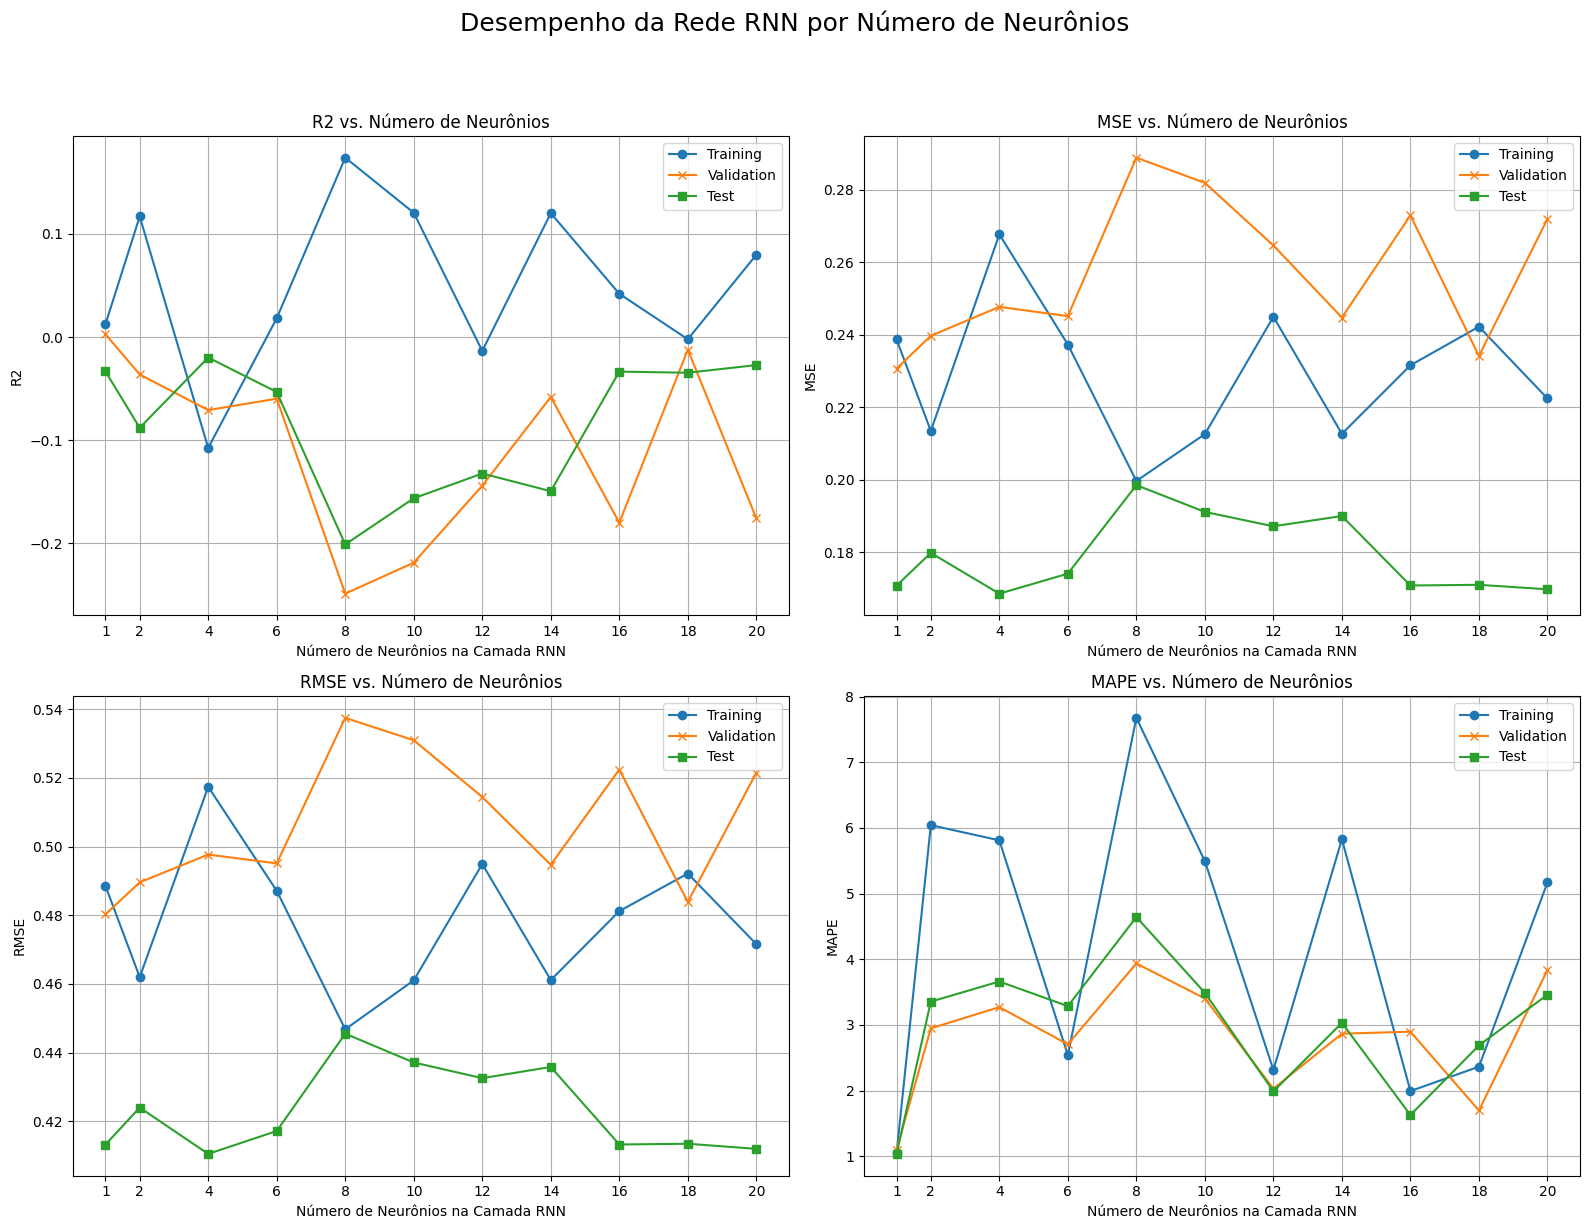

In [75]:
estructured_single_RNN = [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
all_models_metrics = []
tf.random.set_seed(42)

for units in estructured_single_RNN:
    
    print(f"Treinando modelo com {units} neuronios RNN...")
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[TIMESTEPS, FEATURES]),
        keras.layers.SimpleRNN(units, return_sequences=False),
    keras.layers.Dense(1)
    ])
    metrics_model = custom_train_model_with_es(
    model, 
    train_x=train_x_tensor, train_y=train_y_tensor,
    x_val=x_val_tensor, y_val=y_val_tensor,
    x_test=x_test_tensor, y_test=y_test_tensor,
    epochs=5000, 
    learning_rate=0.001, plot=False
)
    metrics_model['RNN_Neurons'] = units
    all_models_metrics.append(metrics_model)

plot_model_metrics_by_neurons(all_models_metrics)

In [ ]:
estructured_single_RNN = [5, 10, 15, 20, 25, 30]
all_models_metrics = []
tf.random.set_seed(42)

for units in estructured_single_RNN:
    print(f"Treinando modelo com {units} neuronios RNN...")
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(units, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(units, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(10),
        keras.layers.Dense(1)
    ])
    metrics_model = custom_train_model_with_es(model, plot= False, patience= 10)
    metrics_model['RNN_Neurons'] = units
    all_models_metrics.append(metrics_model)

plot_model_metrics_by_neurons(all_models_metrics)

In [ ]:
import optuna
import tensorflow as tf
from tensorflow import keras
# ... (suas funções custom_train_model_with_es, pinn_loss, etc. e dados de treinamento) ...

# 1. Definir a Função Objetivo
def objective(trial):
    # Sugerir hiperparâmetros
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True) # Exemplo de LR logarítmico
    rnn_units_1 = trial.suggest_int('rnn_units_1', 10, 50, step=5) # Exemplo de unidades inteiras
    rnn_units_2= trial.suggest_int('rnn_units_2', 5, 50, step=5) # Exemplo de unidades inteiras

    # Definir e compilar o modelo com os hiperparâmetros sugeridos
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(rnn_units_1, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(rnn_units_2),
        keras.layers.Dense(1)
    ])

    # Treinar o modelo usando sua função personalizada
    # Retornamos apenas a val_loss, que queremos minimizar
    metrics = custom_train_model_with_es(model, epochs=1000, patience=10, learning_rate=learning_rate, plot=False)

    # Retornar a métrica de validação que Optuna tentará minimizar
    return metrics['Validation']['MSE'] # ou 'RMSE', 'MAPE', dependendo do seu objetivo

# 2. Criar um Estudo
study = optuna.create_study(direction='minimize') # Queremos minimizar o MSE de validação

# 3. Executar a Otimização
study.optimize(objective, n_trials=50) # Tenta 50 combinações de hiperparâmetros

print(f"Melhor valor (MSE de validação): {study.best_value:.4f}")
print(f"Melhores hiperparâmetros: {study.best_params}")

# Você pode então usar study.best_params para treinar seu modelo final